# 패키지 및 데이터

In [1]:
# ==================================================
# 기본 라이브러리
# ==================================================
import numpy as np
import seaborn as sb
import pandas as pd

from matplotlib import pyplot as plt
from pandas import DataFrame, concat



# ==================================================
# scikit-learn 공통
# ==================================================
from sklearn.pipeline import Pipeline

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    learning_curve,
)

from sklearn.preprocessing import StandardScaler


# ==================================================
# 분류 모델
# ==================================================
from sklearn.linear_model import (
    LogisticRegression,
    SGDClassifier,
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    log_loss,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
)

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
)


# ==================================================
# Boosting 계열
# ==================================================
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


# ==================================================
# 사용자 정의 모듈
# ==================================================
from hossam import *


### 데이터

In [2]:
origin = pd.read_csv("CO2 emission by countries.csv", encoding="latin1")
origin.head()
origin.info()
origin.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59620 entries, 0 to 59619
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Country              59620 non-null  object 
 1   Code                 57452 non-null  object 
 2   Calling Code         56097 non-null  object 
 3   Year                 59620 non-null  int64  
 4   CO2 emission (Tons)  59620 non-null  float64
 5   Population(2022)     53116 non-null  float64
 6   Area                 55284 non-null  float64
 7   % of World           55284 non-null  object 
 8   Density(km2)         53116 non-null  object 
dtypes: float64(3), int64(1), object(5)
memory usage: 4.1+ MB


(59620, 9)

In [6]:
def describe_with_outliers(df):
    """
    describe()에 IQR / Z-Score 이상치 분석 열을 추가한 확장 버전
    추가 정보: 이상치 하한/상한 경계값, 이상치 개수, 이상치 비율(%)
    """
    desc = df.describe()

    numeric_cols = df.select_dtypes(include=[np.number]).columns

    # ── IQR 방식 ───────────────────────────────────────────────
    Q1  = df[numeric_cols].quantile(0.25)
    Q3  = df[numeric_cols].quantile(0.75)
    IQR = Q3 - Q1

    iqr_lower = Q1 - 1.5 * IQR
    iqr_upper = Q3 + 1.5 * IQR

    iqr_outlier_count = ((df[numeric_cols] < iqr_lower) |
                         (df[numeric_cols] > iqr_upper)).sum()
    iqr_outlier_ratio = (iqr_outlier_count / len(df) * 100).round(2)

    # ── Z-Score 방식 ───────────────────────────────────────────
    z_lower = df[numeric_cols].mean() - 3 * df[numeric_cols].std()
    z_upper = df[numeric_cols].mean() + 3 * df[numeric_cols].std()

    z_outlier_count = ((df[numeric_cols] < z_lower) |
                       (df[numeric_cols] > z_upper)).sum()
    z_outlier_ratio = (z_outlier_count / len(df) * 100).round(2)

    # ── describe()에 행 추가 ───────────────────────────────────
    desc.loc["IQR_lower"]       = iqr_lower
    desc.loc["IQR_upper"]       = iqr_upper
    desc.loc["IQR_outlier_n"]   = iqr_outlier_count
    desc.loc["IQR_outlier_%"]   = iqr_outlier_ratio

    desc.loc["Z_lower"]         = z_lower
    desc.loc["Z_upper"]         = z_upper
    desc.loc["Z_outlier_n"]     = z_outlier_count
    desc.loc["Z_outlier_%"]     = z_outlier_ratio

    return desc


# ── 사용 예시 ──────────────────────────────────────────────────
# origin 데이터프레임에 바로 적용
result = describe_with_outliers(origin)
result


,Year,CO2 emission (Tons),Population(2022),Area
count,59620.000,59620.000,53116.000,55284.000
mean,1885.000,1034773694.740,39922597.597,652207.304
std,78.231,10416517783.536,148236484.483,1865482.578
min,1750.000,0.000,11312.000,21.000
25%,1817.000,0.000,1770414.500,17704.500
50%,1885.000,0.000,8673095.000,110381.500
75%,1953.000,8715092.000,28629200.500,492573.000
max,2020.000,417000000000.000,1425887337.000,17098242.000
IQR_lower,1613.000,-13072638.000,-38517764.500,-694598.250
IQR_upper,2157.000,21787730.000,68917379.500,1204875.750


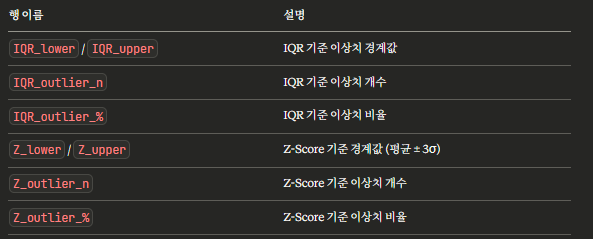

### hs_describe

In [8]:
def hs_describe(data, columns=None):
    """
    수치형 변수 요약 통계 + 결측/이상치/왜도 기반 분포 해석 함수
    """

    # ── 수치형 컬럼 자동 추출
    num_columns = list(data.select_dtypes(include=np.number).columns)

    if not columns:
        columns = num_columns

    # ── 기본 기술통계
    desc = data[columns].describe().T

    # ── 결측치 개수 / 비율
    na_counts = data[columns].isnull().sum()
    desc.insert(1, "na_count", na_counts)
    desc.insert(2, "na_rate", (na_counts / len(data)) * 100)

    # ── 추가 통계 저장용
    additional_stats = []

    for f in columns:
        # 수치형 변수만 처리
        if f not in num_columns:
            continue

        # ── 사분위수
        q1 = data[f].quantile(0.25)
        q3 = data[f].quantile(0.75)
        iqr = q3 - q1

        # ── 이상치 기준 (Tukey’s fences)
        down = q1 - 1.5 * iqr
        up = q3 + 1.5 * iqr

        # ── 왜도
        skew = data[f].skew()
        abs_skew = abs(skew)

        # ── 이상치 개수 / 비율
        outlier_count = ((data[f] < down) | (data[f] > up)).sum()
        outlier_rate = (outlier_count / len(data)) * 100

        # ── 분포 형태 해석
        if abs_skew < 0.5:
            dist = "거의 대칭"
        elif abs_skew < 1.0:
            dist = "약한 우측 꼬리" if skew > 0 else "약한 좌측 꼬리"
        elif abs_skew < 2.0:
            dist = "중간 우측 꼬리" if skew > 0 else "중간 좌측 꼬리"
        else:
            dist = "극단 우측 꼬리" if skew > 0 else "극단 좌측 꼬리"

        # ── 로그 변환 필요성 판단
        if abs_skew < 0.5:
            log_need = "낮음"
        elif abs_skew < 1.0:
            log_need = "중간"
        else:
            log_need = "높음"

        additional_stats.append({
            "field": f,
            "iqr": iqr,
            "down": down,
            "up": up,
            "outlier_count": outlier_count,
            "outlier_rate": outlier_rate,
            "skew": skew,
            "dist": dist,
            "log_need": log_need,
        })

    # ── 추가 통계 DataFrame
    additional_df = DataFrame(additional_stats).set_index("field")

    # ── 결과 병합
    result = concat([desc, additional_df], axis=1)

    return result

In [10]:
desc = hs_describe(origin)
desc

,count,na_count,na_rate,mean,std,min,25%,50%,75%,max,iqr,down,up,outlier_count,outlier_rate,skew,dist,log_need
Year,59620.000,0,0.000,1885.000,78.231,1750.000,1817.000,1885.000,1953.000,2020.000,136.000,1613.000,2157.000,0,0.000,0.000,거의 대칭,낮음
CO2 emission (Tons),59620.000,0,0.000,1034773694.740,10416517783.536,0.000,0.000,0.000,8715092.000,417000000000.000,8715092.000,-13072638.000,21787730.000,13024,21.845,23.528,극단 우측 꼬리,높음
Population(2022),53116.000,6504,10.909,39922597.597,148236484.483,11312.000,1770414.500,8673095.000,28629200.500,1425887337.000,26858786.000,-38517764.500,68917379.500,5149,8.636,8.355,극단 우측 꼬리,높음
Area,55284.000,4336,7.273,652207.304,1865482.578,21.000,17704.500,110381.500,492573.000,17098242.000,474868.500,-694598.250,1204875.750,6504,10.909,5.688,극단 우측 꼬리,높음


In [ ]:
origin.isna().sum()


before = origin.shape[0]

df2 = origin.copy()
df2.head()
d = df2.dropna()

# DataFrame() 은 리스트/배열/Series 형태가 필요합니다.
after = d.shape[0]

# before = origin.shape[0]
# after  = d.shape[0] 은 정수(int)이기 때문에 .mean()메서드 적용 불가
# 반드시 수치형으로 변환

before_mean = origin.mean(numeric_only=True)
after_mean = d.mean(numeric_only=True)
od = pd.DataFrame(
    {
        "결측치 제거 전":[before],
        "결측치 제거 후": [after],
        "결측치 제거 전 평균값": before_mean.mean(),
        "결측치 제거 후 평균값": after_mean.mean()
       
    }
)

od




,결측치 제거 전,결측치 제거 후,결측치 제거 전 평균값,결측치 제거 후 평균값
0,59620,48509,268837596.160,300811233.042


### 행 개수 + 평균 한 번에 정리

In [ ]:
summary = pd.DataFrame({
    "rows": [origin.shape[0], d.shape[0]],
}, index=["before_dropna", "after_dropna"])

mean_compare = pd.DataFrame({
    "before_mean": origin.mean(numeric_only=True),
    "after_mean": d.mean(numeric_only=True)
})

summary
mean_compare


,before_mean,after_mean
Year,1885.000,1885.000
CO2 emission (Tons),1034773694.740,1160748250.497
Population(2022),39922597.597,41861989.536
Area,652207.304,632807.134


### 분석 관점에서 더 좋은 비교

In [ ]:
pd.concat(
    [
        origin.mean(numeric_only=True),
        d.mean(numeric_only=True)
    ],
    axis=1,
    keys=["Before", "After"]
)
 

,Before,After
Year,1885.000,1885.000
CO2 emission (Tons),1034773694.740,1160748250.497
Population(2022),39922597.597,41861989.536
Area,652207.304,632807.134


### 평균 변화량 계산 코드

In [ ]:
mean_compare = pd.concat(
    [
        origin.mean(numeric_only=True),
        d.mean(numeric_only=True)
    ],
    axis=1
)

mean_compare.columns = ["Before", "After"]
mean_compare["Difference"] = (
    mean_compare["After"] - mean_compare["Before"]
)

mean_compare


,Before,After,Difference
Year,1885.000,1885.000,0.000
CO2 emission (Tons),1034773694.740,1160748250.497,125974555.757
Population(2022),39922597.597,41861989.536,1939391.939
Area,652207.304,632807.134,-19400.170


### 어떤 칼럼이 가장 많이 줄었는지 자동 탐색

In [ ]:
# 칼럼별 결측 개수 비교
na_compare = pd.DataFrame({
    "결측 전 NA 개수": origin.isna().sum(),
    "결측 전 NA 비율(%)": origin.isna().mean() * 100
}).sort_values("결측 전 NA 비율(%)", ascending=False)

na_compare


,결측 전 NA 개수,결측 전 NA 비율(%)
Population(2022),6504,10.909
Density(km2),6504,10.909
Area,4336,7.273
% of World,4336,7.273
Calling Code,3523,5.909
Code,2168,3.636
Country,0,0.000
Year,0,0.000
CO2 emission (Tons),0,0.000


### 데이터 전처리

In [ ]:
# 다른 데이터프레임으로 reset_index()
df = origin.copy()
df.reset_index().rename(columns = {"index":"Hello"})

,Hello,Country,Code,Calling Code,Year,CO2 emission (Tons),Population(2022),Area,% of World,Density(km2)
0,0,Afghanistan,AF,93,1750,0.000,41128771.000,652230.000,0.40%,63/km²
1,1,Afghanistan,AF,93,1751,0.000,41128771.000,652230.000,0.40%,63/km²
2,2,Afghanistan,AF,93,1752,0.000,41128771.000,652230.000,0.40%,63/km²
3,3,Afghanistan,AF,93,1753,0.000,41128771.000,652230.000,0.40%,63/km²
4,4,Afghanistan,AF,93,1754,0.000,41128771.000,652230.000,0.40%,63/km²
...,...,...,...,...,...,...,...,...,...,...
59615,59615,Zimbabwe,ZW,263,2016,736467042.000,16320537.000,390757.000,0.30%,42/km²
59616,59616,Zimbabwe,ZW,263,2017,746048675.000,16320537.000,390757.000,0.30%,42/km²
59617,59617,Zimbabwe,ZW,263,2018,757903042.000,16320537.000,390757.000,0.30%,42/km²
59618,59618,Zimbabwe,ZW,263,2019,768852126.000,16320537.000,390757.000,0.30%,42/km²


In [ ]:
#reset_index()를 통해 항목 계산, 칼럼 하나가 더 생김
df1 = df['Country'].value_counts().reset_index()

df1.columns = ['Country', 'COUNT']

df1

,Country,COUNT
0,Afghanistan,271
1,Palestine,271
2,New Zealand,271
3,Nicaragua,271
4,Niger,271
...,...,...
215,Greece,271
216,Greenland,271
217,Grenada,271
218,Guadeloupe,271


In [ ]:
# pd.concat()공부


### 2개의 연속형 칼럼 CO2 emission (Tons) x Population(2022) 계산